In [509]:
import io
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm, laplace, poisson, binom, cauchy, gamma, beta, chi2, expon
from scipy.optimize import curve_fit
from sklearn.mixture import GaussianMixture as GM
from scipy.stats import bootstrap, iqr

TAP_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
query = """SELECT pl_orbper, pl_rade, pl_eqt, st_met, discoverymethod FROM pscomppars"""
r = requests.get(TAP_URL, params={"query": query, "format": "csv"}, timeout=120)
exo = pd.read_csv(io.StringIO(r.text))
exo.head()

,pl_orbper,pl_rade,pl_eqt,st_met,discoverymethod
0,1.003934,1.710000,1419.0,-0.05,Transit
1,8.172400,3.323214,858.0,-0.06,Transit
2,6.283855,0.800000,1108.0,0.07,Transit
3,3.173917,3.150000,1655.0,0.08,Transit
4,56.358501,4.540605,419.0,-0.20,Transit


In [511]:
#Filtriramo podatke tako da zadržimo samo redove koji imaju podatke za sve tri ključne kolone
exo_analiza = exo.dropna(subset=["pl_orbper", "pl_rade", "st_met"])

In [513]:
#Uslovi za selekciju vrucih jupitera
VJ= exo_analiza[(exo_analiza["pl_orbper"] < 10) & (exo_analiza["pl_rade"] > 8)]

In [515]:
#Udeo vrucih jupitera u procentima
udeo = len(VJ) / len(exo_analiza) * 100
print('', np.round(udeo,2), '%')

 12.8 %


In [517]:
#Zvezde velike metalicnosti
ZVM = exo_analiza[exo_analiza["st_met"] > 0.4]

In [519]:
#Vruci Jupiteri oko zvezda velikih metalicosti
VJZVM = ZVM[(ZVM["pl_orbper"] < 10) & (ZVM["pl_rade"] > 8)]

In [521]:
#Udeo vrucih Jupitera oko zvezda visoke metaličnosti
udeoVJZM= len(VJZVM) / len(ZVM) * 100
print('', np.round(udeoVJZM,2), '%')

 37.84 %


Pokazali smo da je udeo vrućih Jupitera veći kod zvezda veće metaličnosti

In [524]:
#Izvlacimo podatke za metalicnost
podaci = exo.loc[exo["st_met"] > 0.4, "st_met"].dropna().values
print(len(podaci))

77


In [526]:
#Bootstrap metoda

m = len(podaci)
n = 1000
np.random.seed(42)

#Uzoracke vrednosti
XSR = podaci.mean()
SDEV = podaci.std(ddof=1)

print("Srednja vrednost metaličnosti XSR =", XSR)
print("Uzoračka standardna devijacija SDEV =", SDEV)

#Boostrap srednja vresnost
#rez_x = bootstrap((podaci,), lambda x: np.std(x, ddof=1), n_resamples=n)
rez_x = bootstrap((podaci,), lambda x: np.mean(x), n_resamples=n)
x_bootstrap = rez_x.bootstrap_distribution

#Boostrap standardna devijacija
rez_s = bootstrap((podaci,),lambda x: np.std(x, ddof=1),n_resamples=n)
s_bootstrap = rez_s.bootstrap_distribution

#Analiticke neodredjenosti
sigma_x = SDEV / np.sqrt(m)
sigma_s = SDEV / np.sqrt(2 * (m - 1))

print()
print("Analitička neodređenost srednje vrednosti:")
print("sigma_x =", sigma_x)

print()
print("Analitička neodređenost standardne devijacije:")
print("sigma_s =", sigma_s)

#Boostrap neodredjenost
sigma_x_bootstrap = x_bootstrap.std(ddof=1)
sigma_s_bootstrap = s_bootstrap.std(ddof=1)

print()
print("Bootstrap neodređenost srednje vrednosti:")
print("sigma_x_bootstrap =", sigma_x_bootstrap)

print()
print("Bootstrap neodređenost standardne devijacije:")
print("sigma_s_bootstrap =", sigma_s_bootstrap)



Srednja vrednost metaličnosti XSR = 0.4544753246753246
Uzoračka standardna devijacija SDEV = 0.06353087967744953

Analitička neodređenost srednje vrednosti:
sigma_x = 0.007240015671030045

Analitička neodređenost standardne devijacije:
sigma_s = 0.005153034793481672

Bootstrap neodređenost srednje vrednosti:
sigma_x_bootstrap = 0.00711795891264492

Bootstrap neodređenost standardne devijacije:
sigma_s_bootstrap = 0.01167635924204766


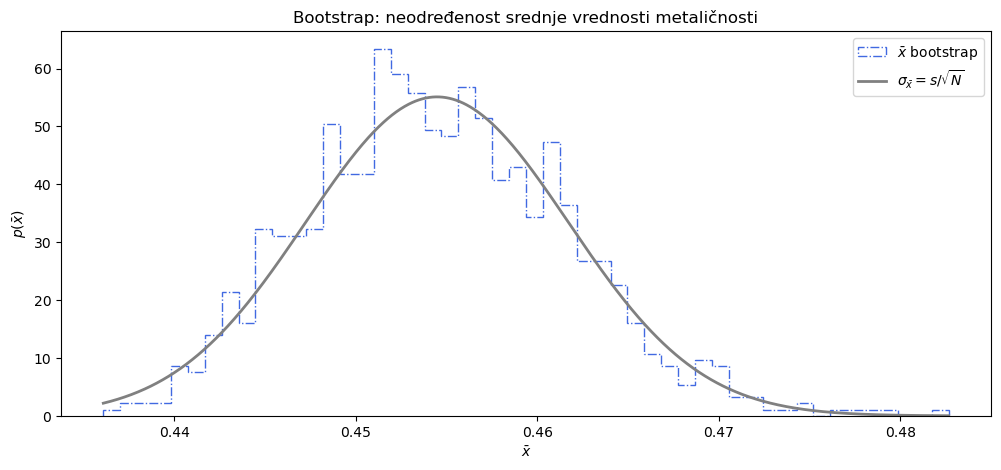

In [528]:
#Plot Bootstrap raspodele srednje vrednosti
xgrid = np.linspace(x_bootstrap.min(), x_bootstrap.max(), 1000)
pdf_x = norm(XSR, sigma_x).pdf(xgrid)


plt.figure(figsize=(12, 5))
plt.hist(x_bootstrap,bins=50,density=True,histtype='step',lw=1,color='royalblue',ls='-.',label=r'$\bar{x}$ bootstrap')
plt.plot(xgrid,pdf_x,color='grey',lw=2,label=r'$\sigma_{\bar{x}} = s/\sqrt{N}$')

plt.xlabel(r'$\bar{x}$')
plt.ylabel(r'$p(\bar{x})$')
plt.legend()
plt.title(r'Bootstrap: neodređenost srednje vrednosti metaličnosti')
plt.show()

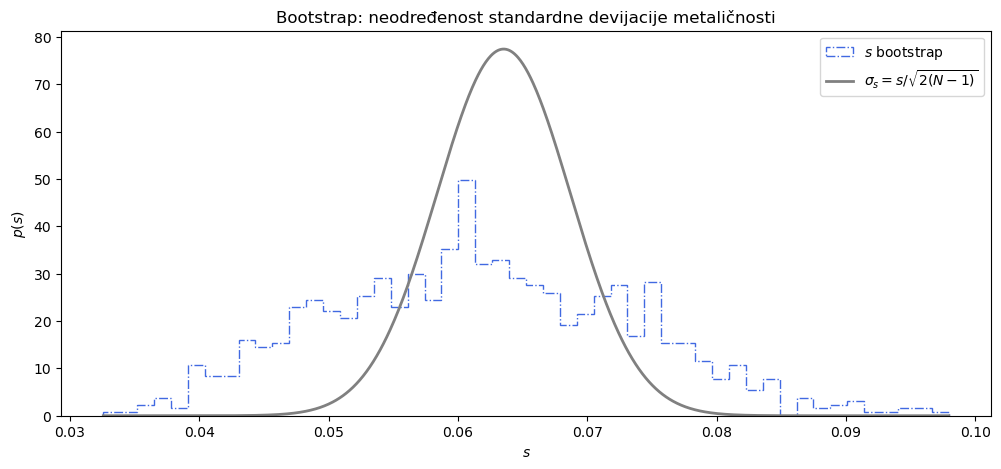

In [530]:
#Plot Bootstrap raspodele standardne devijacije 
xgrid = np.linspace(s_bootstrap.min(), s_bootstrap.max(), 1000)
pdf_s = norm(SDEV, sigma_s).pdf(xgrid)

plt.figure(figsize=(12, 5))
plt.hist(s_bootstrap,bins=50,density=True,histtype='step',lw=1,color='royalblue',ls='-.',label=r'$s$ bootstrap')
plt.plot(xgrid,pdf_s,color='grey',lw=2,label=r'$\sigma_s = s/\sqrt{2(N-1)}$')

plt.xlabel(r'$s$')
plt.ylabel(r'$p(s)$')
plt.legend()
plt.title(r'Bootstrap: neodređenost standardne devijacije metaličnosti')
plt.show()


Bootstrap raspodela uzoračke srednje vrednosti $\bar{x}$ za metaličnost pokazuje dobro približavanje normalnoj raspodeli. To je očekivano, jer se za srednju vrednost može primeniti centralna granična teorema. Sa druge strane, bootstrap raspodela uzoračke standardne devijacije $s$ nije potpuno simetrična i primetno odstupa od normalnog oblika, pošto je standardna devijacija pozitivno definisana veličina i nelinearno zavisi od podataka u uzorku.

Jackknife metoda bi mogla dati zadovoljavajuću procenu neodređenosti srednje vrednosti, ali bi za standardnu devijaciju bila manje pouzdana. Razlog je to što jackknife ne opisuje dovoljno dobro varijabilnost nelinearnih statistika. Zbog toga je u ovom slučaju bootstrap pogodniji metod za procenu neodređenosti.

3 GaussianMixture(n_components=3)


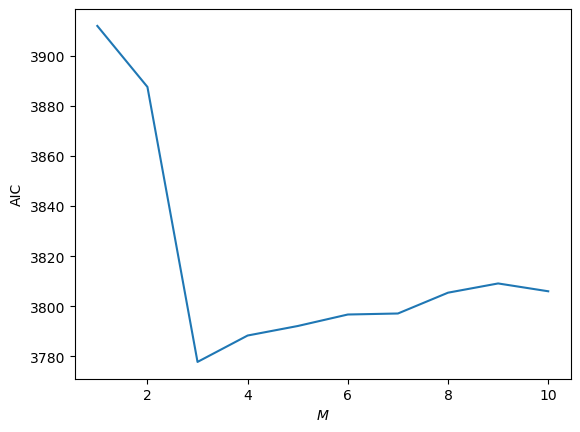

In [533]:
#Iz pdf-a
rs = np.random.RandomState(seed=1)
X = np.concatenate([rs.normal(-1,1.5,350),rs.normal(0, 1, 500),rs.normal(3, 0.5,150)]).reshape(-1, 1)

N = np.arange(1, 11)
modeli = [None for i in range(len(N))]

for i in range(len(N)):
    modeli[i]=GM(N[i]).fit(X)

AIC = [m.aic(X) for m in modeli]
najbolje_N = N[np.argmin(AIC)]
najbolji_model = modeli[np.argmin(AIC)]
print(najbolje_N, najbolji_model)

plt.plot(N, AIC)
plt.xlabel('$M$')
plt.ylabel('AIC')
plt.show( )

In [566]:
#exo["pl_rade"] uzima samo radijuse planeta
#dropna() kao i gore briše nan vrednosti
#.values pretvara brednosti u np niz
#reshape(-1, 1) menja oblik niza iz redova u jednu kolonu
R = exo["pl_rade"].dropna().values
logR = np.log10(R)
X1 = logR.reshape(-1, 1)

N = np.arange(1, 11)
modeli1 = [None for i in range(len(N))]

for i in range(len(N)):
    modeli1[i] = GM(N[i]).fit(X1) #od podataka podesava gausa preko njih za svaki model

AIC1 = [m.aic(X1) for m in modeli1] #Lista od 10 AIC (rezultata)
najbolje_N1 = N[np.argmin(AIC1)] #uzima najmanji AIC iz liste AIC
najbolji_model1 = modeli1[np.argmin(AIC1)]

print("Najbolji broj komponenti M =", najbolje_N1)
print(najbolji_model1)


Najbolji broj komponenti M = 8
GaussianMixture(n_components=8)


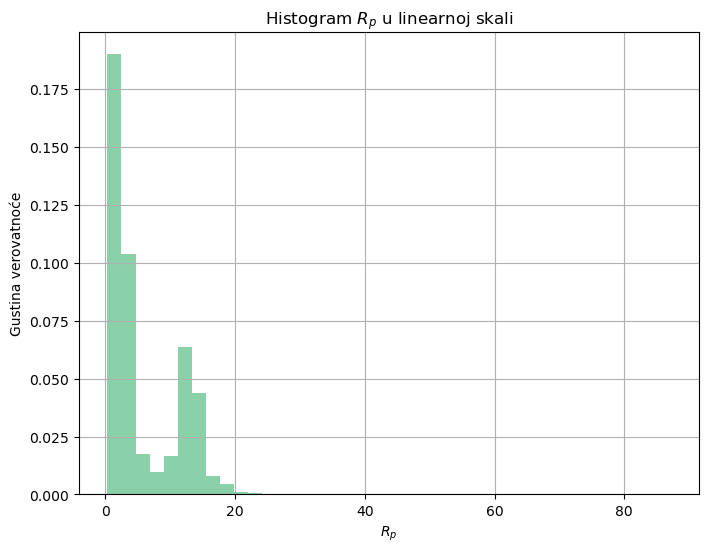

In [568]:
#Cisto da vidimo sta se desava sa podacima kada ih ne stavimo u logaritamsku skalu
plt.figure(figsize=(8,6))
plt.hist(R, bins=40, density=True, alpha=0.6, color='mediumseagreen')
plt.title(r"Histogram $R_p$ u linearnoj skali")
plt.xlabel(r'$R_p$')
plt.ylabel('Gustina verovatnoće')
plt.grid()
plt.show()

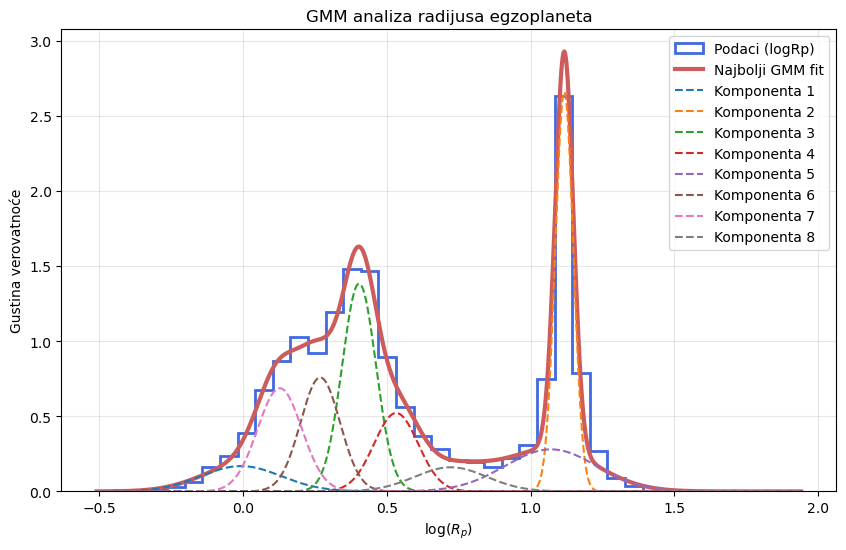

In [574]:
#
x = np.linspace(X1.min(), X1.max(), 1000).reshape(-1, 1) #Pravljenje glatke linije prilagodjene podacima 

#Računanje gustine verovatnoće (PDF) za ukupni model i pojedinačne grupe
logprob = najbolji_model1.score_samples(x)
resp = najbolji_model1.predict_proba(x)
pdf = np.exp(logprob)
pdf_i = resp * pdf[:, np.newaxis]

#Crtanje grafika
plt.figure(figsize=(10, 6))
plt.hist(X1, bins=40, density=True, histtype='step', color='royalblue', lw=2, label='Podaci (logRp)')
plt.plot(x, pdf, color='indianred', lw=3, label='Najbolji GMM fit')
#Automatsko crtanje onoliko komponenti koliko je AIC izabrao da je najbolje
for i in range(pdf_i.shape[1]):
    plt.plot(x, pdf_i[:, i], ls='--', lw=1.5, label=f'Komponenta {i+1}')

plt.title("GMM analiza radijusa egzoplaneta")
plt.xlabel(r'$\log(R_p)$')
plt.ylabel('Gustina verovatnoće')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [541]:
#Izdvajam one koje su otkrivene metodom tranzita
tranzit = exo[exo["discoverymethod"] == "Transit"] 

R_t = tranzit["pl_rade"].dropna().values
logR_t = np.log10(R_t)
X_t = logR_t.reshape(-1, 1)

In [543]:
#Sve isto za tranzite
N = np.arange(1, 11)
modeli2 = [None for i in range(len(N))]

for i in range(len(N)):
    modeli2[i] = GM(N[i]).fit(X_t)

AIC2 = [m.aic(X_t) for m in modeli2]
najbolje_N2 = N[np.argmin(AIC2)]
najbolji_model2 = modeli2[np.argmin(AIC2)]

print("Najbolji broj komponenti M =", najbolje_N2)
print(najbolji_model2)


Najbolji broj komponenti M = 6
GaussianMixture(n_components=6)


In [545]:
#Sve isto kao u proslom samo izmenjeni parametri
x2 = np.linspace(X_t.min(), X_t.max(), 1000).reshape(-1, 1)

#Računanje gustine verovatnoće (PDF) za ukupni model i pojedinačne grupe
logprob2 = najbolji_model2.score_samples(x2)
resp2 = najbolji_model2.predict_proba(x2)
pdf2 = np.exp(logprob2)
pdf_i2 = resp2 * pdf2[:, np.newaxis]

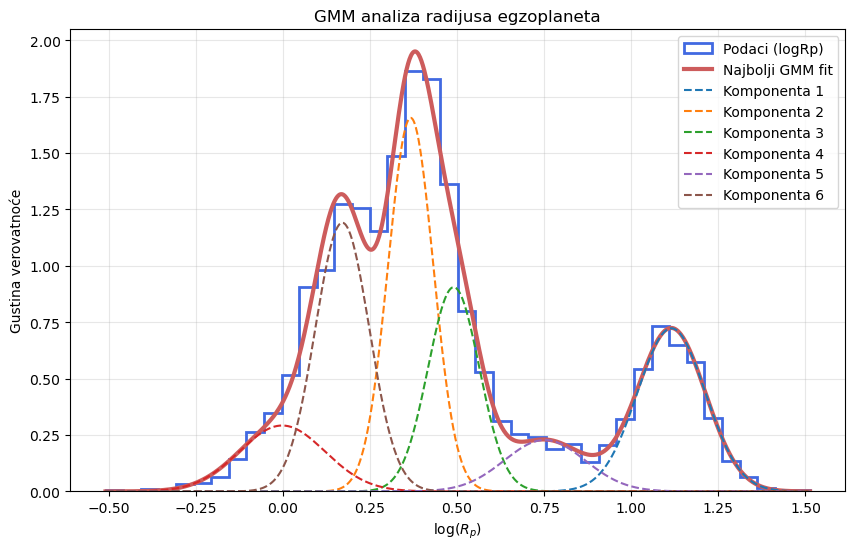

In [547]:
#Crtanje grafika
plt.figure(figsize=(10, 6))
plt.hist(X_t, bins=40, density=True, histtype='step', color='royalblue', lw=2, label='Podaci (logRp)')
plt.plot(x2, pdf2, color='indianred', lw=3, label='Najbolji GMM fit')
for i in range(pdf_i2.shape[1]):
    plt.plot(x2, pdf_i2[:, i], ls='--', lw=1.5, label=f'Komponenta {i+1}') #Automatsko crtanje onoliko komponenti koliko je AIC izabrao da je najbolje

plt.title("GMM analiza radijusa egzoplaneta")
plt.xlabel(r'$\log(R_p)$')
plt.ylabel('Gustina verovatnoće')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

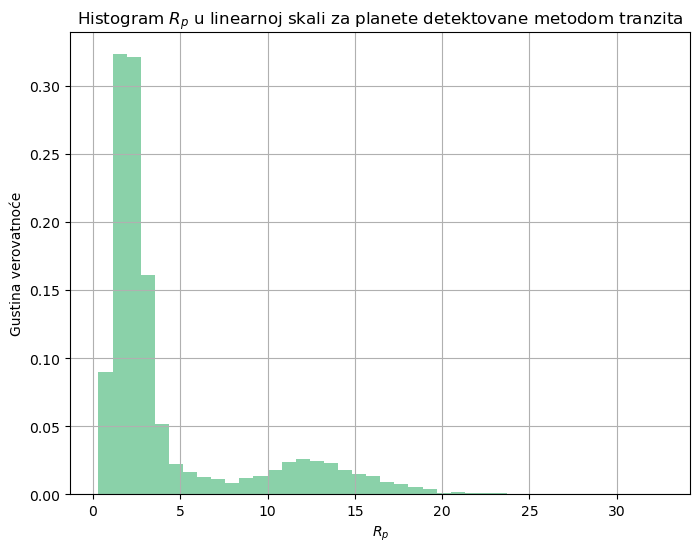

In [549]:
#Opet samo da vidimo podatke koji nisu logaritmovani
plt.figure(figsize=(8,6))
plt.hist(R_t, bins=40, density=True, alpha=0.6, color='mediumseagreen')
plt.title(r"Histogram $R_p$ u linearnoj skali za planete detektovane metodom tranzita")
plt.xlabel(r'$R_p$')
plt.ylabel('Gustina verovatnoće')
plt.grid()
plt.show()

Kada se planetarni radijusi prikažu u logaritamskoj skali $\log_{10}(R_p)$, u raspodelama se mogu uočiti izraženi padovi, odnosno praznine. Najjasnije se vidi praznina između približno $\log R_p = 0.5$ i $\log R_p = 1$. Ova oblast odgovara tzv. Fultonovoj praznini, koja razdvaja dve populacije egzoplaneta: manje stenovite planete, odnosno Super-Zemlje, i veće planete sa značajnim gasovitim omotačem, odnosno Sub-Neptune.

Fultonova praznina se najčešće objašnjava procesom fotoevaporacije. Planete koje se nalaze blizu svojih matičnih zvezda primaju jako zračenje, zbog čega mogu izgubiti deo ili skoro celu gasovitu atmosferu. Na taj način neke planete koje bi inače bile Sub-Neptuni ostaju ogoljene i prelaze u populaciju manjih stenovitih planeta.

In [552]:
query = """SELECT
    pl_name,
    hostname,
    pl_eqt,
    sy_snum,
    sy_pnum,
    disc_telescope,
    pl_bmasse,
    pl_orbeccen
    FROM pscomppars
    """

r = requests.get(TAP_URL,params={"query": query,"format": "csv"},timeout=120) #Slanje zahteva ka NASA arhivi
r.raise_for_status() #Provera da li je zahtev uspesno prosao
exo_temp = pd.read_csv(io.StringIO(r.text)) #Ucitavanje CSV teksta u pandas DataFrame
Teq_Zemlja = 255 # Zemljina temperatura u kelvinima
exo_temp_valid = exo_temp.dropna(subset=["pl_eqt"]).copy() #Izbacujemo planete za koje nije poznata ravnotezna temperatura
exo_temp_valid["razlika_Teq"] = abs(exo_temp_valid["pl_eqt"] - Teq_Zemlja) ## Racunamo apsolutnu razliku izmedju temperature planete i Zemljine temperature
idx = exo_temp_valid["razlika_Teq"].idxmin() #Nalazimo indeks planete kod koje je ta razlika najmanja
najbliza_planeta = exo_temp_valid.loc[idx] #Izdvajamo red koji odgovara toj planeti



In [556]:
print("Planeta čija je ravnotežna temperatura najbliža Zemljinoj:")
print()
print(f"Ime planete: {najbliza_planeta['pl_name']}")
print(f"Ime zvezde/sistema: {najbliza_planeta['hostname']}")
print(f"Ravnotežna temperatura planete: {najbliza_planeta['pl_eqt']} K")
print(f"Razlika u odnosu na Zemljinu Teq: {najbliza_planeta['razlika_Teq']} K")
print()
print(f"Broj zvezda u sistemu: {najbliza_planeta['sy_snum']}")
print(f"Broj planeta u sistemu: {najbliza_planeta['sy_pnum']}")
print(f"Teleskop kojim je planeta otkrivena: {najbliza_planeta['disc_telescope']}")
print(f"Masa planete: {najbliza_planeta['pl_bmasse']} M_Zemlje")
print(f"Ekscentricitet orbite: {najbliza_planeta['pl_orbeccen']}")

Planeta čija je ravnotežna temperatura najbliža Zemljinoj:

Ime planete: HD 40307 g
Ime zvezde/sistema: HD 40307
Ravnotežna temperatura planete: 255.0 K
Razlika u odnosu na Zemljinu Teq: 0.0 K

Broj zvezda u sistemu: 1
Broj planeta u sistemu: 5
Teleskop kojim je planeta otkrivena: 3.6 m ESO Telescope
Masa planete: 7.1 M_Zemlje
Ekscentricitet orbite: 0.29


In [558]:
#
Teq = exo["pl_eqt"].dropna().values #Uzimamo ravnotenu temperaturu planeta
Teq = Teq[np.isfinite(Teq)] #Izbacujemo eventualne beskonacne 
Teq = Teq[Teq > 0] #Isto i za nepozitivne vrednosti
N = len(Teq) #Broj podataka
Teq_sort = np.sort(Teq) #Sortiramo vrednosti Teq
F_ecdf = np.arange(1, N + 1) / N # Empirijska kumulativna raspodela

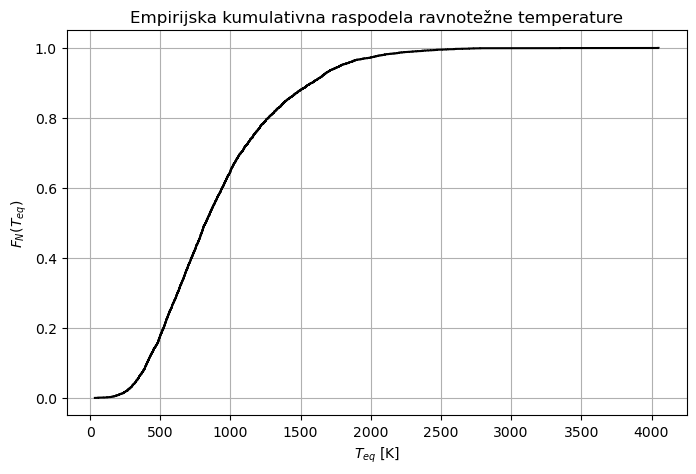

In [560]:
#Crtanje grafika
plt.figure(figsize=(8, 5))
plt.step(Teq_sort,F_ecdf,where="post",color="black")
plt.xlabel(r"$T_{eq}$ [K]")
plt.ylabel(r"$F_N(T_{eq})$")
plt.title("Empirijska kumulativna raspodela ravnotežne temperature")
plt.grid()
plt.show()

In [562]:
#
N_syn = 1000 #Broj sintetickih uzoraka
np.random.seed(42) #Da bi rezultat bio ponovljiv
u = np.random.uniform(0, 1, N_syn) #Generisemo uniformne slucajne brojeve iz u(0,1)
Teq_syn = np.interp(u, F_ecdf, Teq_sort) #Inverzna interpolacija preko ECDF-a

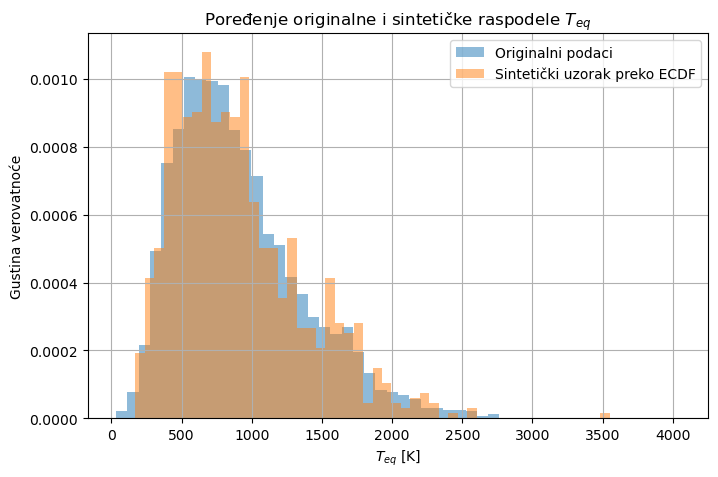

In [564]:
#Crtanje histograma
plt.figure(figsize=(8, 5))
plt.hist(Teq,bins=50,density=True,alpha=0.5,label="Originalni podaci")
plt.hist(Teq_syn,bins=50,density=True,alpha=0.5,label="Sintetički uzorak preko ECDF")
plt.xlabel(r"$T_{eq}$ [K]")
plt.ylabel("Gustina verovatnoće")
plt.title(r"Poređenje originalne i sintetičke raspodele $T_{eq}$")
plt.legend()
plt.grid()
plt.show()

ECDF inverzno uzorkovanje i bootstrap metoda nisu ista procedura, iako obe polaze od empirijskih, odnosno posmatranih podataka.

Kod bootstrap metode novi uzorci se dobijaju reuzorkovanjem originalnog skupa podataka sa vraćanjem. Na taj način se zadržavaju postojeće diskretne vrednosti iz uzorka, kao i osnovna struktura podataka, dok se procenjuje neodređenost neke statistike, na primer srednje vrednosti ili varijanse. Dakle, bootstrap ne pravi model kontinuirane raspodele, već simulira kako bi se posmatrana statistika menjala pri ponovljenom uzorkovanju.

ECDF inverzno uzorkovanje koristi empirijsku kumulativnu raspodelu i preko nje generiše nove sintetičke vrednosti. Ako se koristi interpolacija, ova metoda može dati i vrednosti koje se ne nalaze direktno u originalnom uzorku, već leže između posmatranih tačaka. Zbog toga ECDF inverzno uzorkovanje više služi za generisanje podataka iz empirijske raspodele, dok je bootstrap prvenstveno metoda za procenu neodređenosti statističkih veličina.

Raspodela ravnotežnih temperatura $T_{eq}$ nije simetrična, pa se ne očekuje da se dobro opisuje običnom normalnom raspodelom. Sa histograma se vidi da raspodela ima izraženu asimetriju i rep ka većim vrednostima temperature.

Zbog toga bi pogodniji izbor bila log normalna raspodela. Ravnotežna temperatura zavisi od više fizičkih faktora, kao što su luminoznost zvezde, udaljenost planete od zvezde i albedo. Kada neka pozitivna fizička veličina zavisi od kombinacije više faktora, logaritamska transformacija često daje raspodelu koja je bliža normalnoj.

Log normalna raspodela je pogodna jer je definisana samo za pozitivne vrednosti i prirodno opisuje asimetrične raspodele sa repom ka velikim vrednostima. Kao druga mogućnost mogla bi se koristiti gama raspodela, koja je takođe definisana samo za pozitivne vrednosti i može dobro opisati asimetrične podatke. Ipak, kao prvi izbor za fitovanje $T_{eq}$ izabrao bih log-normalnu raspodelu.